# Liquidity and Order Book Depth

In a modern electronic market, trades interact with liquidity available in the limit order book.

This notebook studies:

- the structure of liquidity in the order book
- bid–ask spread and depth
- order book imbalance
- execution cost and slippage
- liquidity resilience after shocks

The goal is to understand how markets absorb order flow and how liquidity shapes price formation.

## The Role of Liquidity in Market Microstructure

Thanh khoản (liquidity) là khả năng của thị trường hấp thụ các lệnh giao dịch mà **không làm thay đổi giá quá nhiều**.

Một thị trường có thanh khoản cao thường có:

- spread nhỏ
- depth lớn
- slippage thấp

Ba khái niệm quan trọng:

### Bid–Ask Spread

Spread là khoảng cách giữa giá mua tốt nhất và giá bán tốt nhất.

$$
Spread = P_{ask} - P_{bid}
$$

Spread phản ánh **chi phí giao dịch tức thời**.

---

### Market Depth

Depth đo lượng thanh khoản gần mid price.

Ví dụ depth phía bid:

$$
Depth_{bid} = \sum_{i=1}^{L} V_{bid,i}
$$

Trong đó

- $L$ là số mức giá
- $V_{bid,i}$ là volume tại mức bid thứ $i$

Depth càng lớn → thị trường càng dễ hấp thụ các lệnh lớn.

---

### Order Book Imbalance

Imbalance đo sự mất cân bằng giữa lực mua và lực bán:

$$
Imbalance =
\frac{V_{bid} - V_{ask}}
{V_{bid} + V_{ask}}
$$

Nếu imbalance dương → áp lực mua lớn hơn.

Nếu imbalance âm → áp lực bán lớn hơn.

---

Trong notebook này chúng ta sẽ đo các đại lượng này từ simulation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.structure import (
    MarketSimulation,
    OrderBook,
    LiquidityModel,
    PersistentOrderFlow,
    MarketMaker,
)

from src.metrics.microstructure import (
    quoted_spread,
    orderbook_imbalance,
    bid_depth,
    ask_depth,
    total_depth
)

from src.metrics.liquidity_metrics import (
    impact_curve,
    liquidity_resilience
)

## Simulation Setup

Chúng ta sử dụng market simulation để tạo dữ liệu:

- order flow
- trades
- mid price
- order book state

Simulation bao gồm:

1. order flow generator
2. market maker cung cấp liquidity
3. order book để khớp lệnh
4. liquidity model để xử lý execution

In [3]:
orderbook = OrderBook()

liquidity = LiquidityModel()

order_flow = PersistentOrderFlow(
    persistence=0.8,
    min_size=1,
    max_size=20
)

market_maker = MarketMaker(
    base_spread=1.0,
    inventory_limit=500
)

sim = MarketSimulation(
    orderbook=orderbook,
    liquidity_model=liquidity,
    market_maker=market_maker,
    order_flow=order_flow,
    initial_price=100
)

In [4]:
result = sim.run(steps=5000)

prices = result["prices"]
mid_prices = result["mid_prices"]
trades = result["trades"]
events = result["events"]

## Bid–Ask Spread Dynamics

Spread đo chi phí giao dịch tức thời.

$$
Spread = P_{ask} - P_{bid}
$$

Spread phụ thuộc vào:

- liquidity trong orderbook
- inventory risk của market maker
- volatility của thị trường

Trong simulation, chúng ta đo spread theo thời gian.

In [5]:
spreads = []

for _ in range(1000):
    spreads.append(orderbook.spread())

spreads = np.array(spreads)

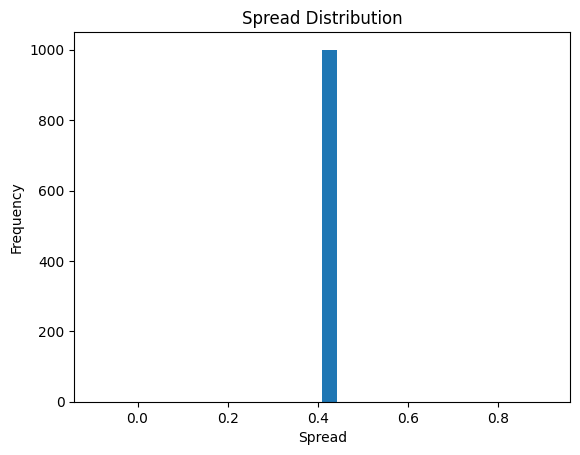

In [6]:
plt.figure()
plt.hist(spreads, bins=30)
plt.title("Spread Distribution")
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.show()

## Order Book Depth

Depth đo tổng thanh khoản gần mid price.

$$
Depth = \sum_{i=1}^{L} V_i
$$

Depth càng lớn thì:

- thị trường càng ổn định
- impact của trade càng nhỏ

In [7]:
depth_series = []

for _ in range(500):
    depth_series.append(total_depth(orderbook))

depth_series = np.array(depth_series)

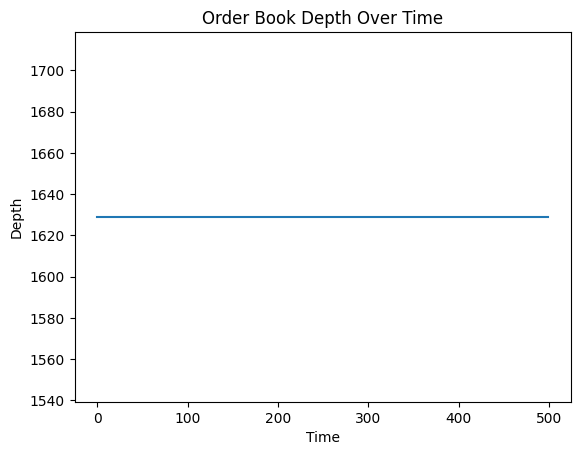

In [8]:
plt.figure()
plt.plot(depth_series)
plt.title("Order Book Depth Over Time")
plt.xlabel("Time")
plt.ylabel("Depth")
plt.show()

## Order Book Imbalance

Order book imbalance phản ánh áp lực mua và bán.

$$
Imbalance =
\frac{V_{bid} - V_{ask}}
{V_{bid} + V_{ask}}
$$

Imbalance thường được dùng để dự đoán biến động giá ngắn hạn.

Nếu:

- imbalance > 0 → lực mua mạnh
- imbalance < 0 → lực bán mạnh

In [9]:
imbalances = []

for _ in range(500):
    imbalances.append(orderbook_imbalance(orderbook))

imbalances = np.array(imbalances)

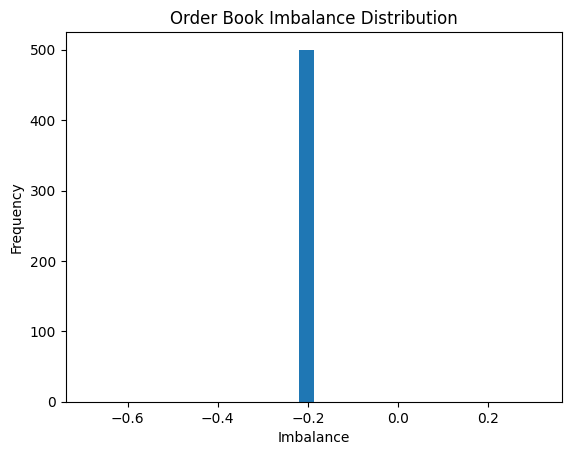

In [10]:
plt.figure()
plt.hist(imbalances, bins=30)
plt.title("Order Book Imbalance Distribution")
plt.xlabel("Imbalance")
plt.ylabel("Frequency")
plt.show()

## Execution Cost and Slippage

Khi một lệnh market order được thực hiện, nó sẽ ăn dần các mức giá trong orderbook.

Execution price vì vậy có thể **khác mid price**.

Slippage được định nghĩa:

$$
Slippage = P_{execution} - P_{mid}
$$

Slippage tăng khi:

- trade size lớn
- orderbook depth nhỏ

In [11]:
sizes = np.linspace(1,200,20)

impacts = impact_curve(orderbook, sizes)

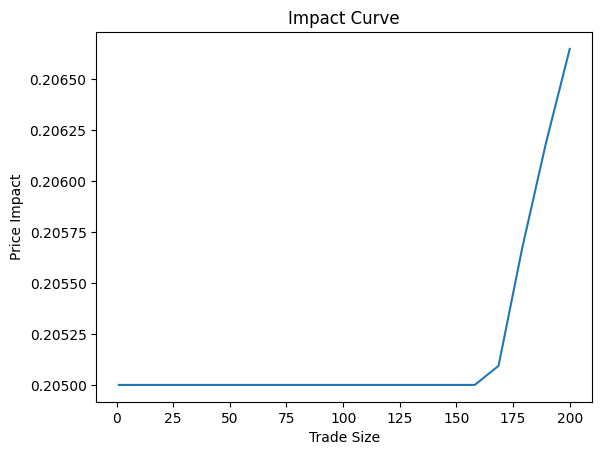

In [12]:
plt.figure()
plt.plot(sizes, impacts)
plt.title("Impact Curve")
plt.xlabel("Trade Size")
plt.ylabel("Price Impact")
plt.show()

## Liquidity Resilience

Sau khi liquidity bị tiêu thụ bởi một trade lớn, thị trường có thể:

- phục hồi nhanh
- hoặc duy trì trạng thái thanh khoản thấp

Liquidity resilience đo tốc độ phục hồi:

$$
Resilience = E[\Delta Depth | \Delta Depth > 0]
$$

Nếu resilience cao → liquidity phục hồi nhanh.

In [13]:
resilience = liquidity_resilience(depth_series)

resilience

0.0

## Price Impact from Liquidity Consumption

Khi một market order đi vào thị trường, nó sẽ tiêu thụ liquidity trong orderbook.

Giá thực thi vì vậy có thể khác mid price.

Price impact được định nghĩa:

$$
I = P_{execution} - P_{mid}
$$

Impact phụ thuộc vào kích thước giao dịch:

$$
I(Q)
$$

Trong nhiều thị trường tài chính, empirical evidence cho thấy:

$$
I(Q) \propto \sqrt{Q}
$$

Điều này được gọi là **square-root impact law**.

Chúng ta sẽ đo impact curve từ orderbook.

In [14]:
sizes = np.linspace(1, 300, 30)

impacts = impact_curve(orderbook, sizes)

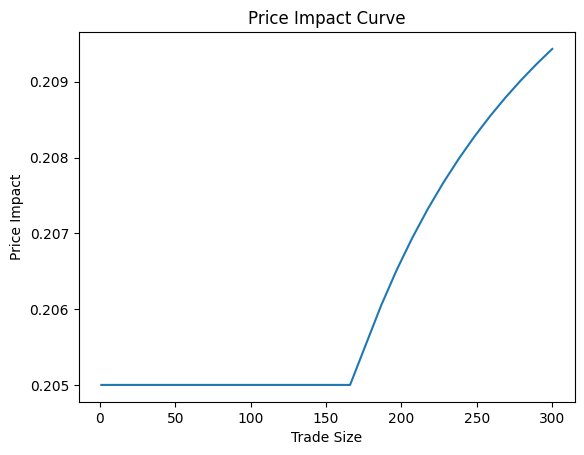

In [15]:
plt.figure()
plt.plot(sizes, impacts)

plt.xlabel("Trade Size")
plt.ylabel("Price Impact")
plt.title("Price Impact Curve")

plt.show()

## Square Root Impact Law

Empirical studies of financial markets show that price impact does not grow linearly with trade size.

Instead, the impact follows an approximate square-root relationship.

$$
I(Q) \propto \sqrt{Q}
$$

Trong đó:

- $Q$ là kích thước giao dịch
- $I(Q)$ là price impact

Điều này có nghĩa:

- trade gấp 4 lần
- impact chỉ tăng khoảng gấp 2 lần

Quan hệ này được quan sát trong nhiều thị trường:

- equities
- futures
- crypto

Square-root impact law phản ánh một đặc điểm quan trọng của liquidity:

- liquidity phân bố theo nhiều mức giá
- orderbook càng sâu → impact tăng chậm hơn theo size

In [16]:
sizes = np.linspace(1, 400, 40)

impacts = impact_curve(orderbook, sizes)

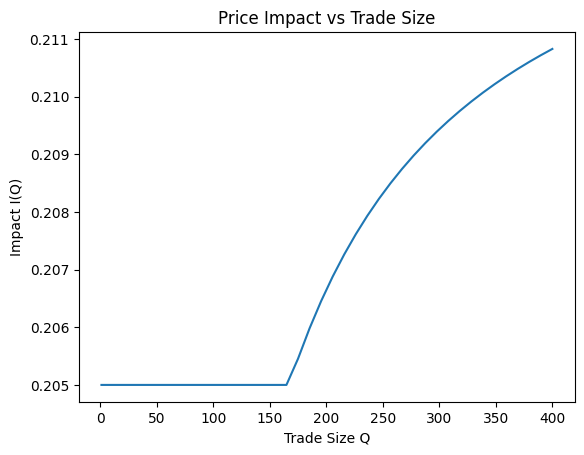

In [17]:
plt.figure()

plt.plot(sizes, impacts)

plt.xlabel("Trade Size Q")
plt.ylabel("Impact I(Q)")
plt.title("Price Impact vs Trade Size")

plt.show()

Nếu square-root law đúng thì:

$$
I(Q) \propto Q^{1/2}
$$

Lấy log hai vế:

$$
\log I(Q) = \frac{1}{2} \log Q + c
$$

Do đó trong log-log plot ta kỳ vọng:

- đường thẳng
- slope ≈ 0.5

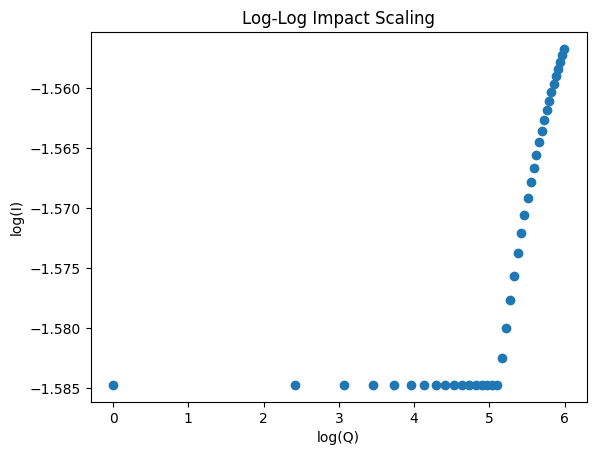

In [18]:
plt.figure()

plt.scatter(np.log(sizes), np.log(impacts))

plt.xlabel("log(Q)")
plt.ylabel("log(I)")

plt.title("Log-Log Impact Scaling")

plt.show()